In [1]:
from pathlib import Path
import joblib
from insilico_stimuli.stimuli import GaborSet, CenterSurround
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from probcs.experiment_running.exc_experiment import center_surround_experiment
from probcs.models.pattern_completion_model import PatternCompletionModel
from sklearn.metrics.pairwise import cosine_similarity

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


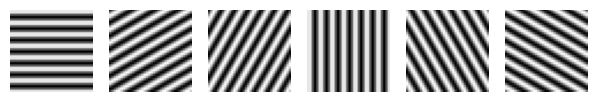

In [11]:

seed = 42

canvas_size                = [36, 36]
locations                  = [[18, 18]]  # center position
sizes_total                = [36]          # total size (center + surround)
sizes_center               = [0.5]           # portion of radius used for center circle
sizes_surround             = [0.5]      # defines the starting portion of radius for surround
contrasts_center           = [1.0]     # try 2 center contrasts
contrasts_surround         = [1.0]          # surround contrast
orientations_center = list(np.linspace(-np.pi/2, np.pi/2, 6, endpoint=False))
orientations_surround = list(np.linspace(-np.pi/2, np.pi/2, 6, endpoint=False))
# orientations_center        = [0.0, np.pi/2, np.pi/4, -np.pi/4]  # variable orientation
# orientations_surround      = [0.0, np.pi/2, np.pi/4, -np.pi/4]  # center only
# orientations_center = list(np.linspace(0, np.pi, 8, endpoint=False))
spatial_frequencies_center = [0.2]           # fixed spatial frequency
phases_center              = [np.pi]  # center phases 
grey_levels                = [0.0]           # fixed grey level
# spatial_frequencies_surround = [0.1, 0.3]  # optional parameter, default: same as spatial_frequencies_center
# phases_surround = [np.pi/4]                # optional parameter, default: same as phases_center

center_surround = CenterSurround(canvas_size=canvas_size, 
        locations=locations,
        sizes_total=sizes_total,
        sizes_center=sizes_center,
        sizes_surround=sizes_surround,
        contrasts_center=contrasts_center,
        contrasts_surround=contrasts_surround,
        orientations_center=orientations_center,
        orientations_surround=orientations_surround,
        spatial_frequencies_center=spatial_frequencies_center,
        phases_center=phases_center,
        grey_levels=grey_levels
)

# gratings_offset = 0.5
gratings = np.array([center_surround.images()[idx] for idx in range(len(center_surround.images())) if center_surround.params_dict_from_idx(idx)['orientation_center'] == center_surround.params_dict_from_idx(idx)['orientation_surround']])
plt.figure(figsize=(10, 5))
for i, img in enumerate(gratings):
        plt.subplot(4, 8, i + 1)
        plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
        plt.axis('off')

In [3]:
orientations_center = list(np.linspace(0, np.pi/2, 4, endpoint=True))

In [4]:
orientations_center

[0.0, 0.5235987755982988, 1.0471975511965976, 1.5707963267948966]

In [7]:
[0.0, np.pi/2, np.pi/4, -np.pi/4]

[0.0, 1.5707963267948966, 0.7853981633974483, -0.7853981633974483]

In [4]:
len(orientations_center)

8

In [2]:
# define all constants here
G_dim = len(gratings)
G_prob = 1/G_dim
x_sigma = .1
I_sigma = 2
offset = 0.3
n_tune = 300
n_draws = 300
n_chains = 1
n_cores = 1

In [3]:
results = center_surround_experiment(
    seed=seed,
    patterns=gratings,
    g_dim=G_dim,
    g_prob=G_prob,
    x_sigma=x_sigma,
    i_sigma=I_sigma,
    patterns_offset=offset,
    n_tune=n_tune,
    n_draws=n_draws,
    n_chains=n_chains,
    n_cores=n_cores
)

Running experiment with config:
seed=42, g_dim=4, g_prob=0.25, x_sigma=0.1, i_sigma=2, pattern_offset=0.3, n_tune=300, n_draws=300, n_chains=1, n_cores=1
Building model ...


Only 300 samples in chain.


Setting up experiment ...
Number of center x dims:  4
Running experiment for center x dim 0/4 ...
Sampling posterior for MEI ...


Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 1 chain for 300 tune and 300 draw iterations (300 + 300 draws total) took 42 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Only 300 samples in chain.


...

Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 1 chain for 300 tune and 300 draw iterations (300 + 300 draws total) took 24 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Only 300 samples in chain.


Running experiment for disruptive surround 2/3 ...


Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 1 chain for 300 tune and 300 draw iterations (300 + 300 draws total) took 63 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [29]:
# define all constants here
G_dim = len(gratings)
G_prob = 1/G_dim*2
x_sigma = .1
I_sigma = 1.5
offset = 0.5
n_tune = 300
n_draws = 300
n_chains = 1
n_cores = 1
results = center_surround_experiment(
    seed=seed,
    patterns=gratings,
    g_dim=G_dim,
    g_prob=G_prob,
    x_sigma=x_sigma,
    i_sigma=I_sigma,
    patterns_offset=offset,
    n_tune=n_tune,
    n_draws=n_draws,
    n_chains=n_chains,
    n_cores=n_cores
)

Running experiment with config:
seed=42, g_dim=4, g_prob=0.5, x_sigma=0.1, i_sigma=1.5, pattern_offset=0.5, n_tune=300, n_draws=300, n_chains=1, n_cores=1
Building model ...
Setting up experiment ...
Number of center x dims:  4
Running experiment for center x dim 0/4 ...
Sampling posterior for MEI ...


Only 300 samples in chain.
Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 1 chain for 300 tune and 300 draw iterations (300 + 300 draws total) took 40 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Only 300 samples in chain.


Sampling posterior for completing surround ...


Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


...

Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 1 chain for 300 tune and 300 draw iterations (300 + 300 draws total) took 9 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks
Only 300 samples in chain.


Running experiment for disruptive surround 2/3 ...


Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [G]
>NUTS: [X]


Sampling 1 chain for 300 tune and 300 draw iterations (300 + 300 draws total) took 15 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [30]:
(
    model,
    all_idata,
    all_stimuli,
    all_g_means,
    all_g_means_sde,
    all_center_x_means,
    all_center_x_means_sde,
    all_center_x_perc_change_means,
    all_center_x_perc_change_means_sde,
) = results

In [31]:
all_g_means

[[array([0., 0., 0., 0.]),
  array([1., 0., 0., 0.]),
  array([0., 1., 0., 0.]),
  array([0., 0., 1., 0.]),
  array([0., 0., 0., 1.])],
 [array([0., 0., 0., 0.]),
  array([0., 1., 0., 0.]),
  array([0.62333333, 0.        , 0.        , 0.        ]),
  array([0., 0., 1., 0.]),
  array([0., 0., 0., 0.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 1., 0.]),
  array([0.57, 0.  , 0.  , 0.  ]),
  array([0., 1., 0., 0.]),
  array([0., 0., 0., 1.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 0., 1.]),
  array([1., 0., 0., 0.]),
  array([0., 1., 0., 0.]),
  array([0., 0., 1., 0.])]]

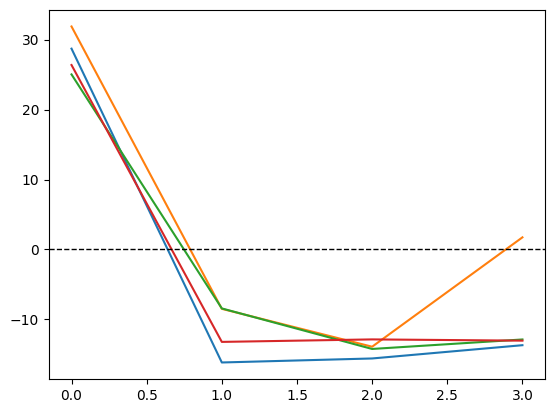

In [32]:
plt.plot(np.array(all_center_x_perc_change_means).T)
# plot a horizontal line at 0
plt.axhline(0, color='black', linestyle='--', linewidth=1)

In [5]:
# import pickle
# with open("hiararhical_idata.pkl", "wb") as f:
#     pickle.dump(all_idata, f)

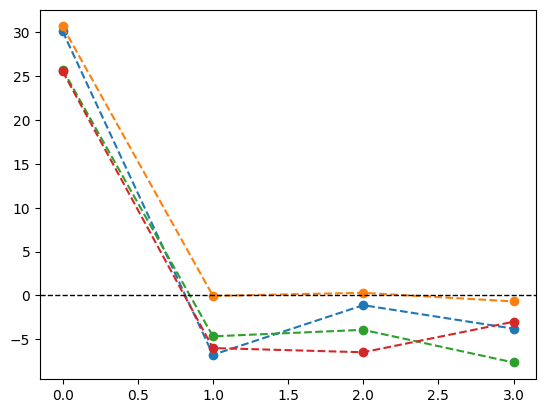

In [25]:
plt.plot(np.array(all_center_x_perc_change_means).T, "--o")
# plot a horizontal line at 0
plt.axhline(0, color='black', linestyle='--', linewidth=1)

In [ ]:
results = center_surround_experiment(
    seed=seed,
    patterns=gratings,
    g_dim=G_dim,
    g_prob=G_prob,
    x_sigma=x_sigma,
    i_sigma=I_sigma,
    patterns_offset=offset,
    n_tune=n_tune,
    n_draws=n_draws,
    n_chains=n_chains,
    n_cores=n_cores
)

ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (4).

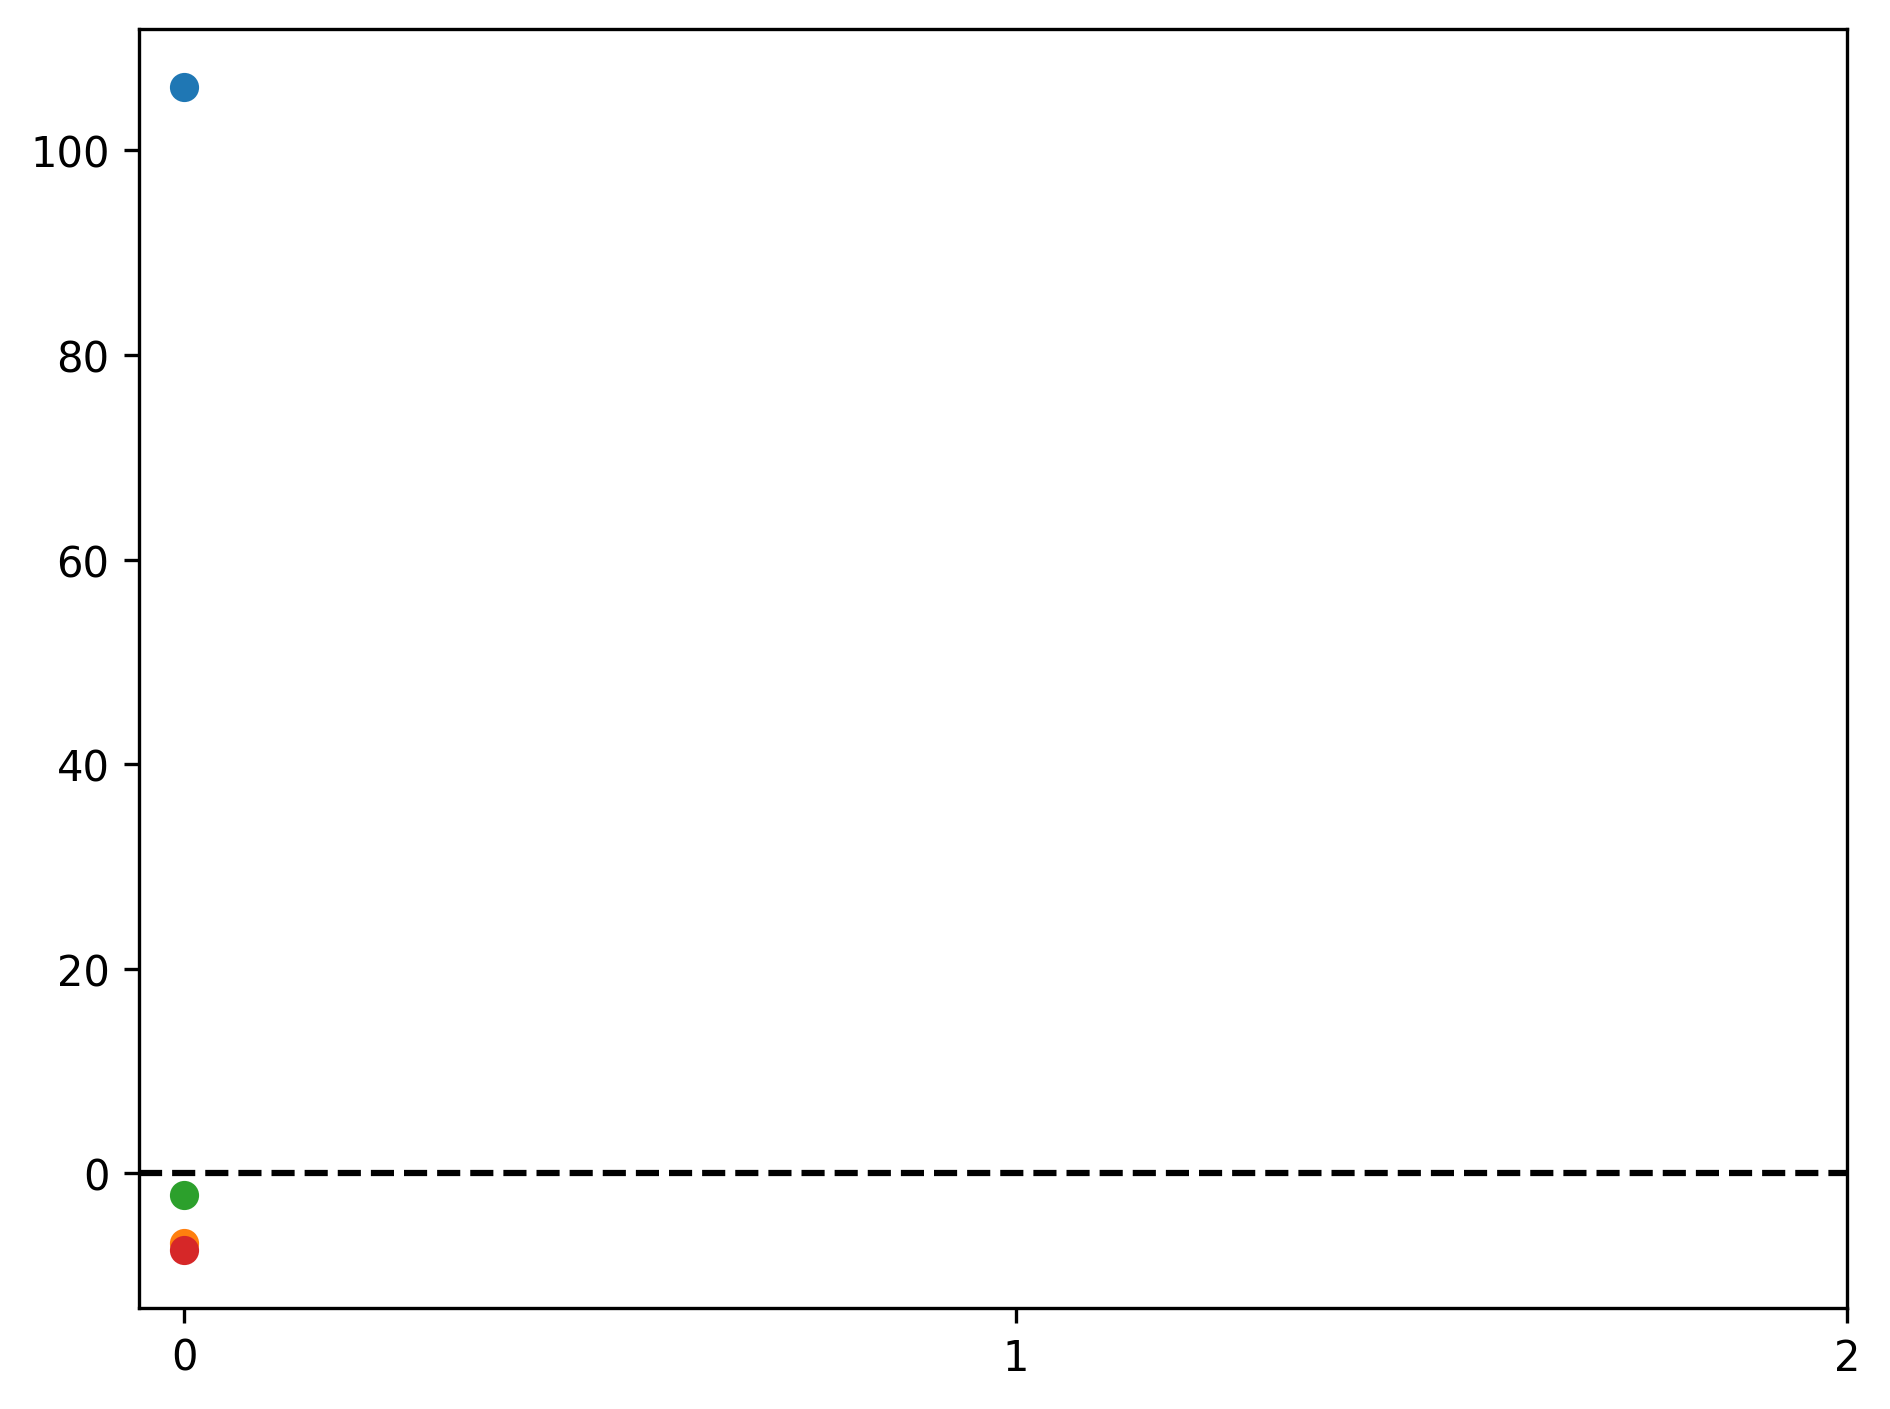

In [15]:
fig, ax = plt.subplots(dpi=300, nrows=1, ncols=1, sharex=True, tight_layout=True)
for means in zip(all_center_x_perc_change_means):
    ax.plot(means, "--o")
    # draw a horizontal line at 0
    ax.axhline(y=0, color="black", linestyle="--")
    ax.set_xticks(range(0, 3))
    ax.set_xticklabels(["C"] + ["D"] * 3)
    # ax.set_xticklabels(["Com"] + ["Dis"] * 8)
    # ax.set_xticklabels(range(9))

In [26]:
all_center_x_perc_change_means

[[30.12236602088738,
  -6.780241941714833,
  -1.1174283658535218,
  -3.801415064026434],
 [30.675688518072082,
  -0.05813792902782028,
  0.29171741113494126,
  -0.6901827687333033],
 [25.762945354987764,
  -4.6743614986828295,
  -3.931960631009609,
  -7.655898516034004],
 [25.553535399005238,
  -6.0106331113525915,
  -6.4909497953748865,
  -3.0083099299522242]]

In [7]:
all_center_x_perc_change_means_sde

[[0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 0.0]]

In [8]:
all_g_means

[[array([0., 0., 0., 0.]),
  array([1., 0., 0., 0.]),
  array([0., 1., 0., 0.]),
  array([0., 0., 1., 0.]),
  array([0., 0., 0., 1.])],
 [array([0., 0., 0., 0.]),
  array([0., 1., 0., 0.]),
  array([1., 0., 0., 0.]),
  array([0., 0., 1., 0.]),
  array([0., 0., 0., 1.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 1., 0.]),
  array([1., 0., 0., 0.]),
  array([0., 1., 0., 0.]),
  array([0., 0., 0., 1.])],
 [array([0., 0., 0., 0.]),
  array([0., 0., 0., 1.]),
  array([1., 0., 0., 0.]),
  array([0., 1., 0., 0.]),
  array([0.        , 0.        , 0.79666667, 0.        ])]]

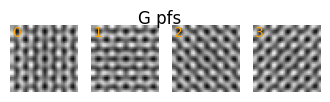

In [ ]:
model.visualize_learned_G(nrows=1, ncols=4)

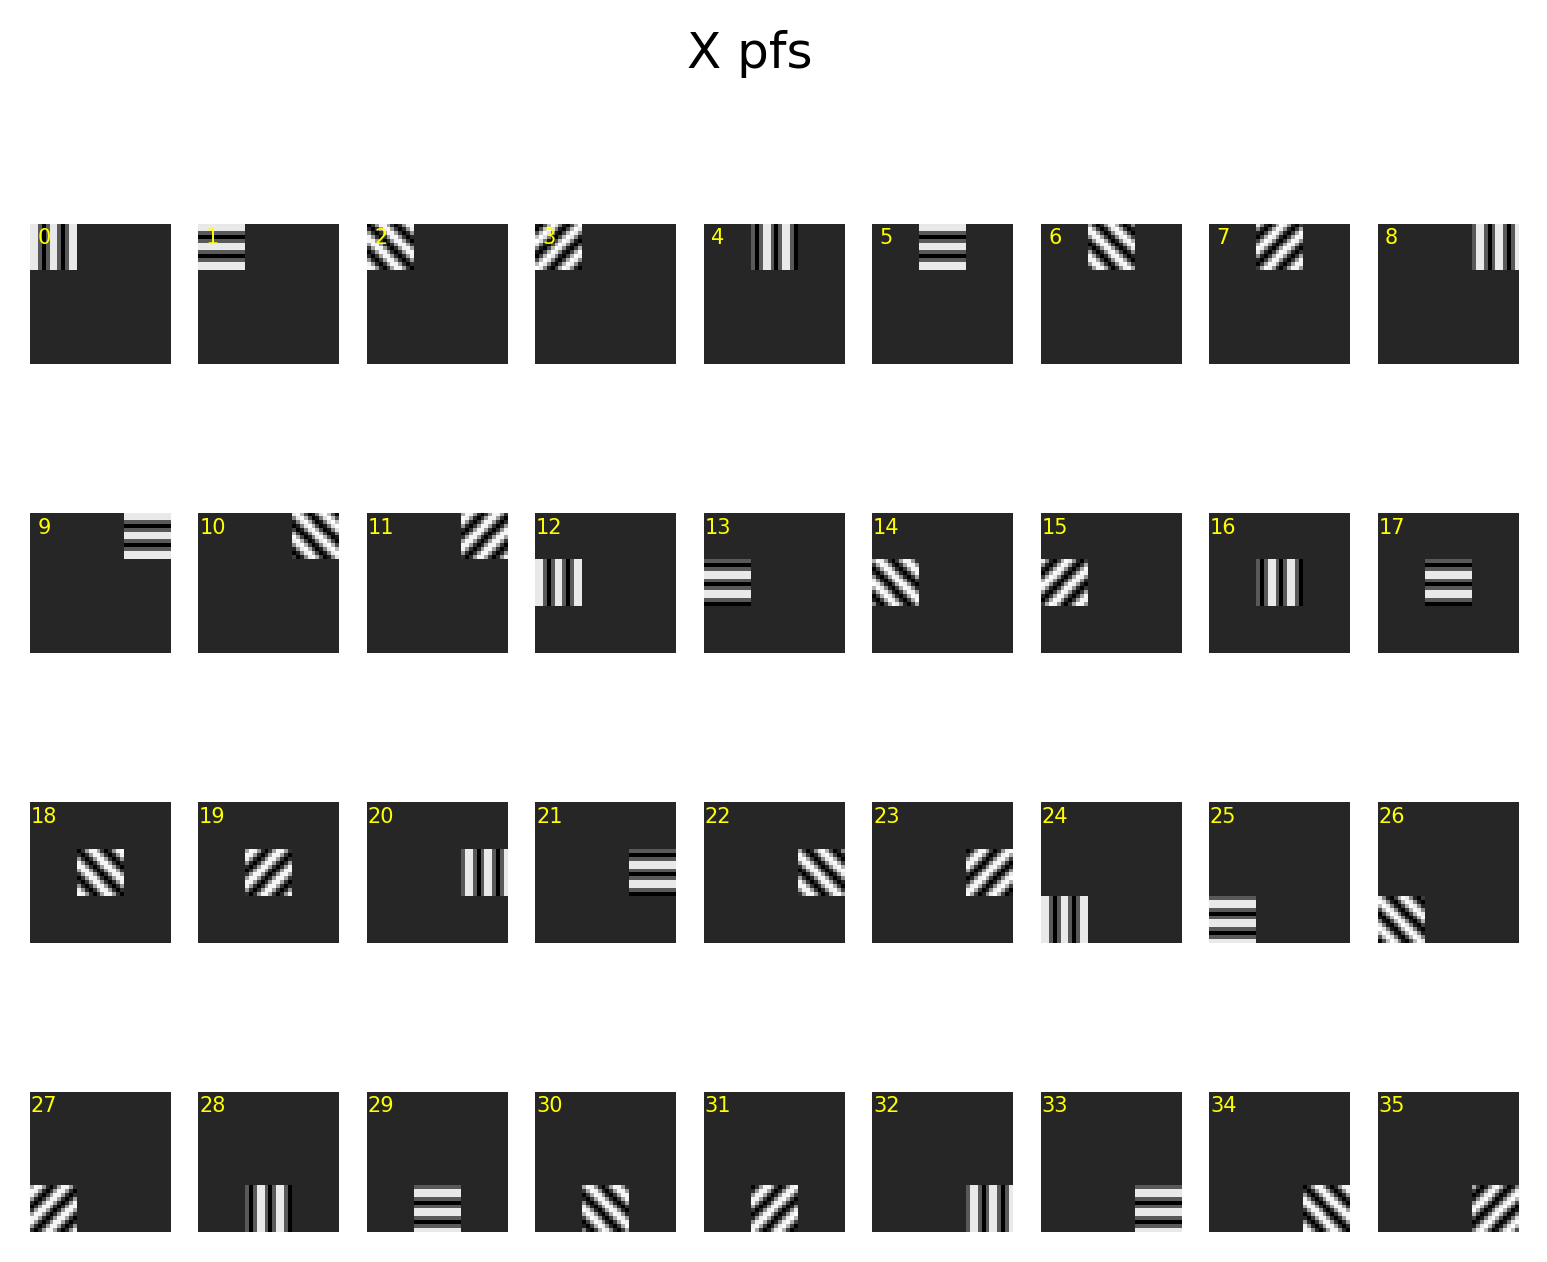

In [ ]:
model.visualize_learned_X(nrows=4, ncols=9)

(-0.5, 35.5, 35.5, -0.5)

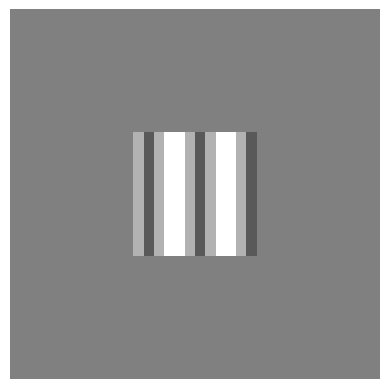

In [ ]:
empty_image = np.zeros((36, 36))
MEI_center = model.grating_crops[4][0].reshape(12, 12).copy()
empty_image[12:24, 12:24] = MEI_center
MEI = empty_image
plt.imshow(MEI, cmap='gray', vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

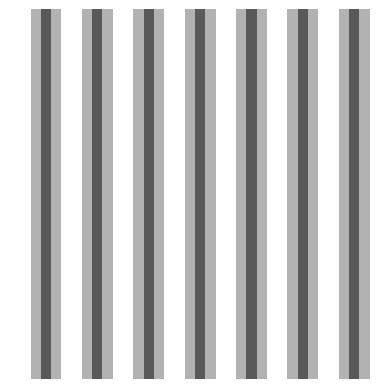

In [ ]:
completing_image = model.gratings[0].copy()
plt.imshow(completing_image, cmap='gray', vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 35.5, 35.5, -0.5)

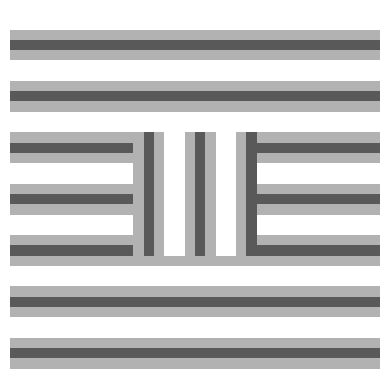

In [ ]:
disrupting_image_1 = model.gratings[1].copy()
disrupting_image_1[12:24, 12:24] = MEI_center.copy()
plt.imshow(disrupting_image_1, cmap='gray', vmin=-1, vmax=1)
plt.axis("off")

In [ ]:
images = [MEI, completing_image, disrupting_image_1]
n_samples = 200
n_tune = 200
all_samples = []
for image in images:
    post_samples = model.sample_posterior(
        image=image,
        n_samples=n_samples,
        random_seed=42,
        tune=n_tune,
        chains=4,
        cores=4
    )
    all_samples.append(post_samples)

Only 200 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CategoricalGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 27 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 200 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CategoricalGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 24 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
Only 200 samples in chain.


reshaped_image (1296,)


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>CategoricalGibbsMetropolis: [G]
>NUTS: [X]


Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 26 seconds.
/usr/local/lib/python3.8/dist-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in double_scalars
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


In [ ]:
n_neurons = 36
all_x_samples_reshaped = []
for samples in all_samples:
    samples = samples['posterior']['X'].data.reshape(4*n_samples, n_neurons)
    all_x_samples_reshaped.append(samples)

In [ ]:
all_x_samples_reshaped = np.array(all_x_samples_reshaped)
print(all_x_samples_reshaped.shape)

(3, 800, 36)


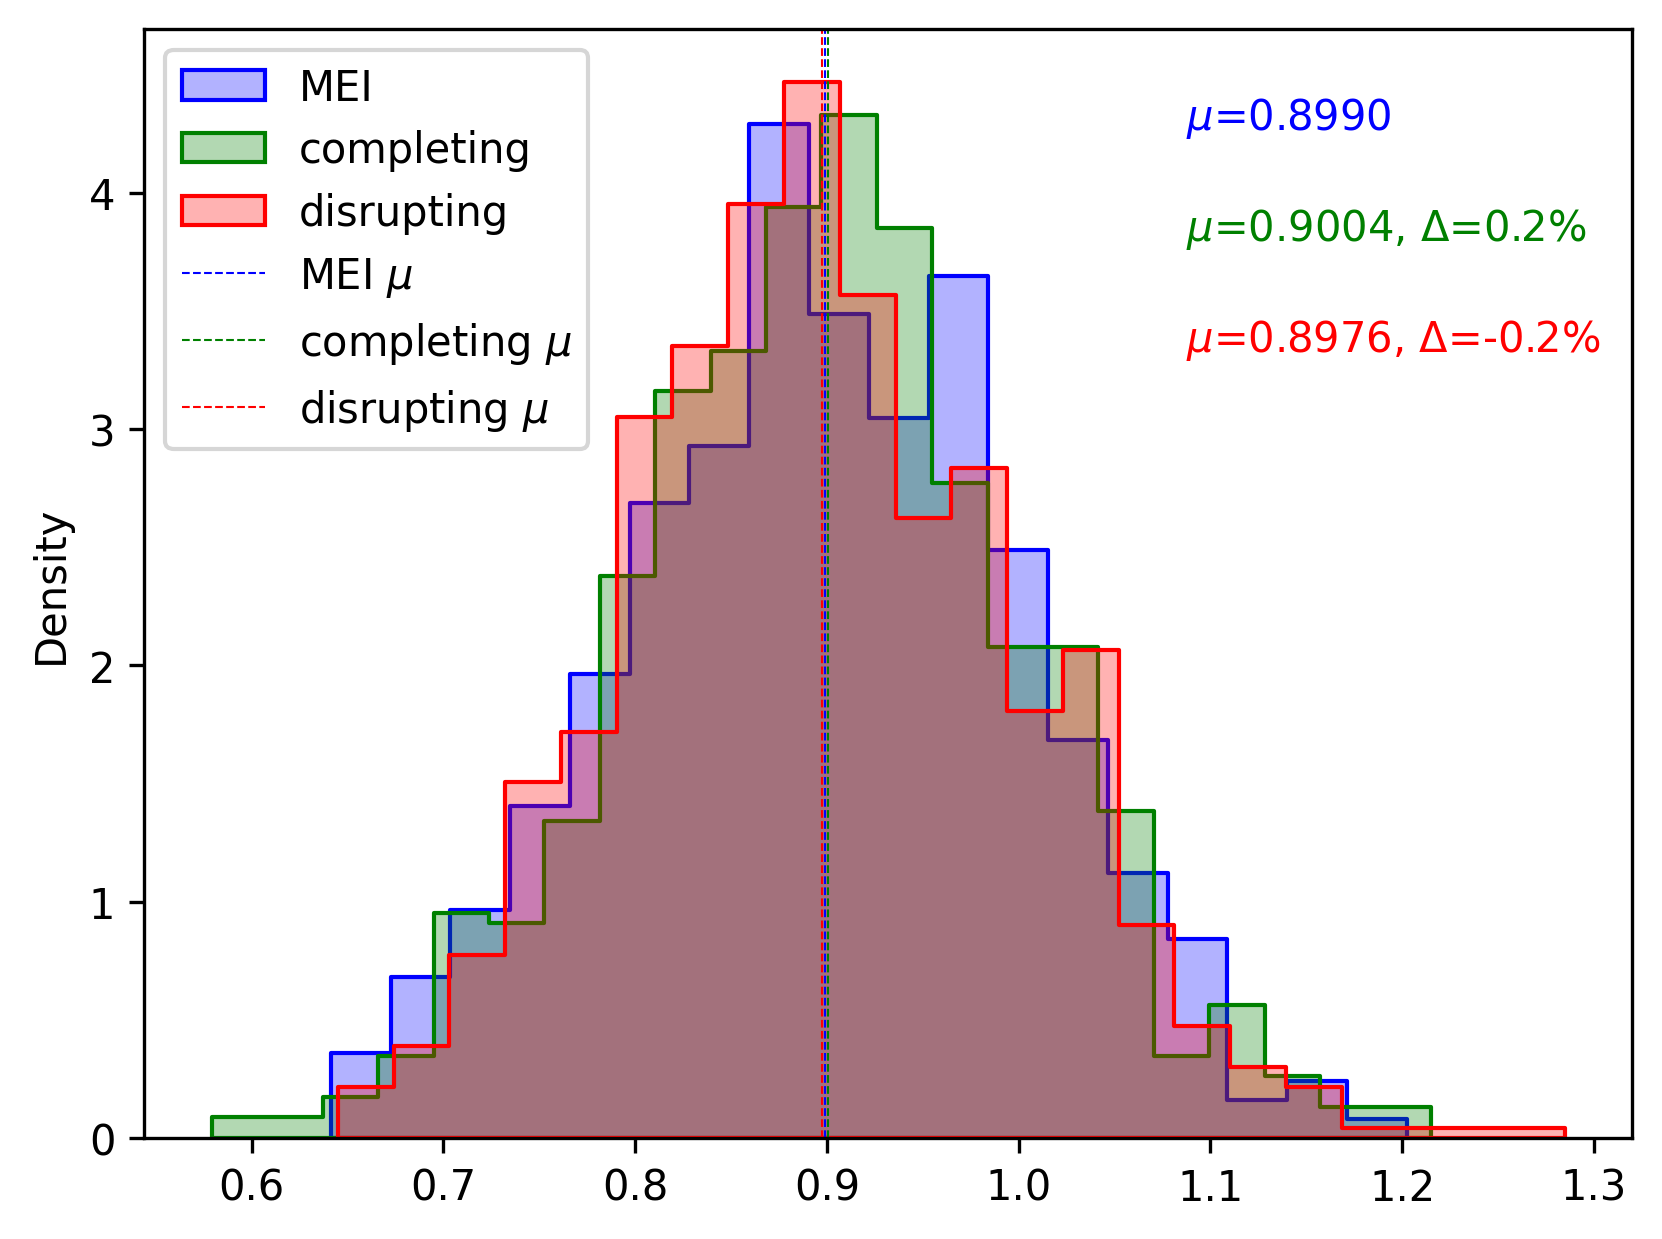

In [ ]:
fig, ax = plt.subplots(dpi=300)
neuron_id = 16
sns.histplot(
    all_x_samples_reshaped[0][:, neuron_id],
    ax=ax,
    stat="density",
    color="blue",
    element="step",
    alpha=0.3,
    label="MEI"
)
sns.histplot(
    all_x_samples_reshaped[1][:, neuron_id],
    ax=ax,
    stat="density",
    color="green",
    element="step",
    alpha=0.3,
    label="completing"
)
sns.histplot(
    all_x_samples_reshaped[2][:, neuron_id],
    ax=ax,
    stat="density",
    color="red",
    element="step",
    alpha=0.3,
    label="disrupting"
)

MEI_mean = np.mean(all_x_samples_reshaped[0][:, neuron_id])
completing_mean = np.mean(all_x_samples_reshaped[1][:, neuron_id])
disrupting_mean = np.mean(all_x_samples_reshaped[2][:, neuron_id])
completing_perc_change = (completing_mean - MEI_mean) / MEI_mean
disrupting_perc_change = (disrupting_mean - MEI_mean) / MEI_mean

ax.text(0.7, 0.9, f"$\mu$={MEI_mean:.4f}", size=10, ha="left", va="bottom", transform=ax.transAxes, color='blue')
ax.text(0.7, 0.8, f"$\mu$={completing_mean:.4f}, $\Delta$={completing_perc_change*100:.1f}%", size=10, ha="left", va="bottom", transform=ax.transAxes, color='green')
ax.text(0.7, 0.7, f"$\mu$={disrupting_mean:.4f}, $\Delta$={disrupting_perc_change*100:.1f}%", size=10, ha="left", va="bottom", transform=ax.transAxes, color='red')

ax.axvline(MEI_mean, color="blue", linestyle="--", linewidth=0.5, label="MEI $\mu$")
ax.axvline(completing_mean, color="green", linestyle="--", linewidth=0.5, label="completing $\mu$")
ax.axvline(disrupting_mean, color="red", linestyle="--", linewidth=0.5, label="disrupting $\mu$")

ax.legend(loc="upper left")